In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
# from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pickle as pkl

<div dir="rtl"> 

    
###  בשיעור קודם דיברנו על כיצד למצוא את האמדים של $b_0$ ו- $b_1$ ואילו הנחות היינו צריכים לקחת בשביל לעשות את זה:

<div dir="rtl"> 

## אבל מה זה בכלל אמד?? ומה אנחנו אומדים?
    
### בסטטיסטיקה יש לנו אוכלסייה מסוימת שעלינו היינו רוצים לדעת כמה דברים, אבל אין לנו דרך להגיע לכל האוכלוסיה אלא רק לחלק מהאוכלוסייה. 
    
#### שאנחנו אומרים חלק מהאוכלוסייה הכוונה היא שיש לנו תצפיות. דרך התצפיות אנחנו אומדים משהו שמתייחס לכל האוכלוסיה
    
#### למשל, הייתי רוצה לדעת מהו הגובה ההממוצע של נשים בישראל. אני לא יכול לדעת את התשובה האמיתית - אבל אני יכול למדוד גובה של חלק מהנשים ובעזרת זה לנחש מהו הגובה הממוצע. 
    
#### הדוגמה הכי קלאסית היא בחירות לכנסת. תמיד רוצים לדעת מדגמים עבור הבחירות. אז שואלים חלק מהאנשים ומזה מסיקים. לרוב אותם מדגמים "מנחשים לא רע" 
    
## נחזור אם כך למושג "אמד": פונקציה של התפציות שבעזרתה "מנחשים" את הערך שאנחנו רוצים לדעת

<div dir="rtl"> 


#### דוגמא:
    
    
#### אנחנו במפעל למתכות מייצרים עמודי פלדה, שאומרים להיות באורך של מטר אחד. ייצרנו 10 עמודים שכולם שונים אחד מהשני באורכם מעט. כיצד נמדוד את התוחלת של העמודים המיוצרים?
    
$$ \hat{\mu} = \bar{X} = \frac{\sum_{i=1}^n X_i}{n} $$
    
###     samples = [0.99, 1.02, 1.2, 0.81, 0.97, 1.01, 1.02, 1.1, 0.95, 0.999]

In [3]:
samples = [0.99, 1.02, 1.2, 0.81, 0.97, 1.01, 1.02, 1.1, 0.95, 0.999]

mean_samp = np.array(samples).mean()
mean_samp

1.0069

<div dir="rtl"> 

    
#### מהו אמד טוב? למה לקחנו את ההממוצע כדי למדוד את התוחלת? למה לא המקסימום של המדגם? או המינימום?
    
#### במקרה של תוחלת ממוצע זה די מתבקש, אבל אם נרצה לאמוד שונות של אוכלוסייה? מה יהיה האמד אז? זה לא תמיד כלכך פשוט. 
    
#### גם לאמוד את $b_0$ $b_1$ לא כלכך טרווייאלי.
    
### בשביל לדעת אם אומד הוא טוב, נרצה לחשב 2 קריטריונים שנרצה שהערך של שניהם יהיה נמוך.
    
## Bias או הטייה: 
    
$$ bias(\hat{\mu}, \mu) = E[\hat{\mu}]- \mu $$
    
### מה זה אומר המדד הזה? הכוונה היא שאם ניקח נשתמש במדד הזה  - בממוצע הוא היה פוגע בערך האמיתי. נדגים: 


$$ E[aX]=aE[X] $$

$$ E[X_1+X_2] = E[X_1]+E[X_2] $$

### $$ E[x_i] = \mu $$

### $$\hat{\mu}  = \bar{x} = \sum_{i=1}^n \frac{x_i}{n}$$

#### $$ E[\hat{\mu} ] = E[\sum_{i=1}^n \frac{x_i}{n}] = \frac{1}{n}E[x_1 +x_2+..+ x_n] 
=\frac{1}{n} (E[x_1]+E[x_2]+.. + E[x_n]) = \frac{1}{n}(n \mu) = \mu$$

In [4]:
samples = []
for ind in range(50):
    sample = np.random.uniform(0.8, 1.2, 10)
    samples.append(sample.mean())
    

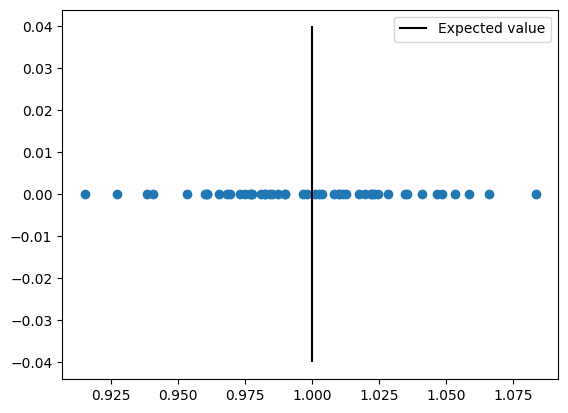

In [5]:
plt.figure()
plt.scatter(samples, np.zeros(50) )
plt.vlines(1, -0.04, 0.04, colors=None, linestyles='solid', label = 'Expected value', color = 'black')
plt.legend()
plt.show()

In [6]:
samples = []
for ind in range(500000):
    sample = np.random.uniform(0.8, 1.2, 10)
    samples.append(sample.mean())
    
np.array(samples).mean()

1.0000122533128064

<div dir="rtl"> 

### אמד שהbias שלו הוא 0 נקרא אמד חסר הטיה. ידוע בקיצור אח"ה 
    
### חשוב לציין - אם נסמן את תוחלת האוכלוסייה ב$\mu$ אזי ש: $E[X_i]=\mu$
    

    
#### קריטריון אחר הוא השונות של האמד:
    
$$ Var[\hat{\mu}] $$
    
   
### חשוב לציין - אם נסמן את שונות האוכלוסייה ב$\sigma^2$ אזי ש: $Var[X_i]=\sigma^2$
   
   
#### בדוגמא לעיל נרצה לדעת מהו השונות של האמד $\bar{X}$. 
    
    
    
$$ Var[\bar{X}] = Var[\sum_{i=1}^n \frac{X_i}{n}] = \frac{1}{n^2}Var[X_1+X_2...+X_n] = \frac{1}{n^2}n \sigma_2 =  \frac{\sigma^2}{n} $$

## נראה שהשונות של האמד קטנה עם n. 
    
#### נדגים: 
    


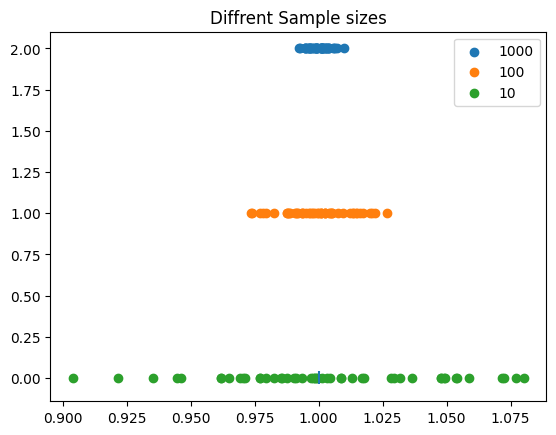

In [7]:
samples_10 = []
for ind in range(50):
    sample = np.random.uniform(0.8, 1.2, 10)
    samples_10.append(sample.mean())
    



samples_100 = []
for ind in range(50):
    sample = np.random.uniform(0.8, 1.2, 100)
    samples_100.append(sample.mean())
    


samples_1000 = []
for ind in range(50):
    sample = np.random.uniform(0.8, 1.2, 1000)
    samples_1000.append(sample.mean())
    
plt.figure()
plt.scatter(samples_1000, 2+ np.zeros(50), label = 1000 )
plt.scatter(samples_100, 1+ np.zeros(50), label = 100 )
plt.scatter(samples_10,  np.zeros(50), label = 10 )

plt.vlines(1, -0.04, 0.04, colors=None, linestyles='solid')
plt.title('Diffrent Sample sizes')
plt.legend()
plt.show()


<div dir="rtl"> 

### ניתן לראות כי ככל שגודל המדגם גדל כך השונות קטנה. 
    
## דוגמא לbiased estimator
    
### נרצה לאמוד את השונות $V[X] = \sigma^2$. בואו ניזכר מהי שונות:
    
### $$ V[X] = E[X-E[X]]^2 $$
    
### אומד הגיוני יהיה: בעזרת n תצפיות $X_1, X_2,...,X_n$
    
### $$ \hat{\sigma^2} = \sum_{i=1}^n \frac{(X_i-\bar{X})^2}{n} $$
    
#### בואו נבחן האם האומד הזה חסר הטייה - כלומר האם:
    
### $$ E[\sum_{i=1}^n \frac{(X_i-\bar{X})^2}{n}] = \sigma^2  $$
    
#### נראה בכיתה כי: 
    
### $$  E[\sum_{i=1}^n \frac{(X_i-\bar{X})^2}{n}] = \frac{n+1}{n}\sigma^2  $$ 
    
    
### כלומר  - לא חסר הטיה. 
    

    

<div dir="rtl">
    
### סיכום ביניים - כאשר אנחנו אומדים פרמטר של אוכללוסיה בעזרת אומד כלשהו נרצה שני דברים שהאומד שלנו תהיה עם הטייה נמוכה, אידיאלית עם הטייה אפסית ושתהיה לו שונות מינימאלית.
    
### אם נרצה לחבר את שני חלקים אלו ניתן לעשות זאת על ידי מדד שנקרא MSE. נניח עבור פרמטר $\theta$
    
### $$ MSE(\hat{\theta}) = E[(\theta-\hat{\theta})^2] = Bias(\hat{\theta})^2 + Var(\hat{\theta})  $$
    
### למשל נשווה בין שני אומדים לשונות: 
    
### 1. $$ \hat{\sigma^2} = \sum_{i=1}^n \frac{(X_i-\bar{X})^2}{n} $$

### הbias שלו הוא 

###   $$  \frac{n+1}{n}\sigma^2 - \sigma^2  = \frac{1}{n}\sigma^2 $$ 

### 2. $$ \hat{\sigma^2} = \sum_{i=1}^n \frac{(X_i-\bar{X})^2}{n-1} $$
    
### הbias שלו הוא 0
    
### לא נראה את החישוב של השונות של שני האומדים האלו רק נציין שהשונות של האומד הראשון קטנה יותר ולמרות שהוא אומד מוטה הMSE שלו גם קטן יותר. 

<div dir="rtl"> 

## איך כל זה קשור לאמדים של $b_0$ ו- $b_1$? 
    
## יותר חשוב, איך כל זה קשור להנחות המודל של שיוויון שונויות ונורמליות?
    
### מסתבר שההנחות האלו מאפשרות שהאמדים הנ"ל יהיו חסרי הטייה ועם שונות מינימלית. 
    
### ישנה תיאוריה סטטיסטית מאחורי זה אבל לא ניכנס להוכחה - אלא רק להבנה הכללית שההנחות האלו מאפשרות אמדים טובים יותר
    
### אם ההנחות לא מתקיימות אזי האמדים יהיו פחות מדויקים